## 1 Create Data


### Load and combine original

In [ ]:
from scripts.data_operation import *

save_data_frame(
    combine_original_data(ORIGINAL_DATA_DIR), 
    filename='combined_data.csv'
)

### Prepare relevant data

In [ ]:
import pandas as pd

from scripts.data_operation import *
from scripts.constants import *

clean_data = pd.read_csv('data/combined_data.csv')

distinct_listings = clean_data['apartment_id'].unique()
listing_indices = {listing: i for i, listing in enumerate(distinct_listings)}

clean_data['apartment_id'] = clean_data['apartment_id'].map(listing_indices)
clean_data['adults_count'] = clean_data['adults_count'].fillna(0).astype(int)
clean_data['children_count'] = clean_data['children_count'].fillna(0).astype(int)
clean_data['infants_count'] = clean_data['infants_count'].fillna(0).astype(int)
clean_data['start_date'] = pd.to_datetime(clean_data['start_date'], errors='coerce')
clean_data['end_date'] = pd.to_datetime(clean_data['end_date'], errors='coerce')
clean_data['price'] = earnings_to_numbers(clean_data['earnings'])
clean_data['beds_count'] = clean_data['adults_count'] + clean_data['children_count'] + clean_data['infants_count']

clean_data['nightly_rate'] = (clean_data['price'] / clean_data['nights_count']).round(0).astype(int)
clean_data['nightly_bed_rate'] = (clean_data['nightly_rate'] / clean_data['beds_count']).round(0).astype(int)

save_data_frame(
    clean_data[RELEVANT_COLUMNS], 
    filename='relevant_data.csv'
)

### Prepare demand data

In [ ]:
import pandas as pd

from scripts.data_operation import *
from scripts.constants import *


relevant_data = pd.read_csv('data/relevant_data.csv', parse_dates=['start_date', 'end_date'])

daily_stays = pd.DataFrame(transform_to_daily_stays(relevant_data))

daily_agg = daily_stays.groupby('stay_date').agg(
    room_nights=('beds_count', 'sum'),
    occupied_apartments=('apartment_id', lambda x: list(x)),
    apartment_bed_rate_pairs=('apartment_bed_rate_pair', lambda x: list(x)),
    avg_bed_rate=('nightly_bed_rate', 'mean'),
    sum_bed_rate=('nightly_bed_rate', 'sum')
)

daily_agg = daily_agg.reset_index()
daily_agg['stay_date'] = pd.to_datetime(daily_agg['stay_date'], errors='coerce')
daily_agg = daily_agg[(daily_agg['stay_date'] >= START_DATE) & (daily_agg['stay_date'] < END_DATE)]

save_data_frame(
    daily_agg,
    filename='daily_aggregated_data.csv'
)


## 2 Data Display

### Listing summary

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

relevant_data = pd.read_csv('data/relevant_data.csv')

listing_summary = relevant_data.groupby('apartment_id').agg(
    avg_nightly_rate=('nightly_rate', 'mean'),
    avg_bed_rate=('nightly_bed_rate', 'mean'),
    avg_people_count=('beds_count', 'mean'),
    max_people_count=('beds_count', 'max'),
    num_reservations=('apartment_id', 'count')
).reset_index()

plt.figure(figsize=(12, 6))
plt.bar(listing_summary['apartment_id'], (listing_summary['avg_bed_rate'])/100, color='skyblue')
plt.xlabel('Apartment ID')
plt.ylabel('Average Nightly Rate')
plt.title('Average Nightly Rate by Apartment ID')
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(listing_summary['apartment_id'], listing_summary['max_people_count'], color='salmon')
plt.bar(listing_summary['apartment_id'], listing_summary['avg_people_count'], color='lightgreen')
plt.xlabel('Apartment ID')
plt.ylabel('Average People Count')
plt.title('Average People Count by Apartment ID')
plt.show()

### Agregated data

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from scripts.data_operation import *

daily_agg = pd.read_csv('data/daily_aggregated_data.csv', parse_dates=['stay_date'])
daily_agg.set_index('stay_date', inplace=True)
# bar plot of daily room nights
daily_agg['room_nights'].plot(figsize=(20, 6), kind='bar', title='Daily Room Nights', color='pink')
plt.xticks(ticks=range(0, len(daily_agg), 7))
plt.xlabel('Date')
plt.ylabel('Room Nights')
plt.show()

## 3 Demand prediction

### Split dataset

In [2]:
import pandas as pd
from scripts.constants import *



daily_agg = pd.read_csv('data/daily_aggregated_data.csv', parse_dates=['stay_date'])
daily_agg = daily_agg.set_index('stay_date').sort_index()
daily_frequency = daily_agg['room_nights'].asfreq('D')

train_series = daily_frequency[:-PREDICTION_HORIZON_DAYS]
test_series = daily_frequency[-PREDICTION_HORIZON_DAYS:]

### Fit auto_arima

In [3]:
from pmdarima import auto_arima

model = auto_arima(
    train_series,
    seasonal=True,
    m=14, # number of days in seasonality
    stepwise=True,
    suppress_warnings=True,
    trace=True
    )

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[14] intercept   : AIC=inf, Time=0.96 sec
 ARIMA(0,1,0)(0,0,0)[14] intercept   : AIC=3364.301, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[14] intercept   : AIC=3280.487, Time=0.12 sec
 ARIMA(0,1,1)(0,0,1)[14] intercept   : AIC=3315.858, Time=0.17 sec
 ARIMA(0,1,0)(0,0,0)[14]             : AIC=3362.304, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[14] intercept   : AIC=3360.572, Time=0.02 sec
 ARIMA(1,1,0)(2,0,0)[14] intercept   : AIC=3217.917, Time=0.34 sec
 ARIMA(1,1,0)(2,0,1)[14] intercept   : AIC=inf, Time=1.32 sec
 ARIMA(1,1,0)(1,0,1)[14] intercept   : AIC=inf, Time=0.43 sec
 ARIMA(0,1,0)(2,0,0)[14] intercept   : AIC=3219.519, Time=0.26 sec
 ARIMA(2,1,0)(2,0,0)[14] intercept   : AIC=3213.269, Time=0.43 sec
 ARIMA(2,1,0)(1,0,0)[14] intercept   : AIC=3275.604, Time=0.16 sec
 ARIMA(2,1,0)(2,0,1)[14] intercept   : AIC=inf, Time=1.61 sec
 ARIMA(2,1,0)(1,0,1)[14] intercept   : AIC=inf, Time=0.81 sec
 ARIMA(3,1,0)(2,0,0)[14] intercept   : AIC=3

### Demand Prediction

In [4]:
forecast_series = model.predict(n_periods=PREDICTION_HORIZON_DAYS)

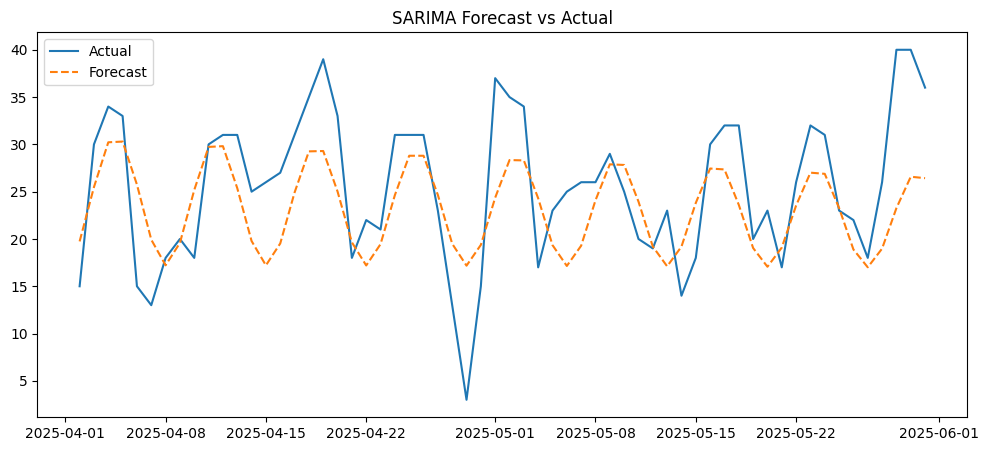

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(test_series.index, test_series, label='Actual')
plt.plot(forecast_series.index, forecast_series, label='Forecast', linestyle='--')
plt.legend()
plt.title('SARIMA Forecast vs Actual')
plt.show()

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(test_series, forecast_series)
rmse = mean_squared_error(test_series, forecast_series, squared=False)
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")


MAE: 5.17, RMSE: 6.30
